<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/ML_In_Chem/Solubility_Reg_1077167_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **SOLUBILITY REGRESSION** - Kwanda Mazibuko stdnr : 1077167

<div style="text-align: center;">
   <img src="https://media.geeksforgeeks.org/wp-content/uploads/20230622125511/Solid-in-water.webp" >
</div>


# **Importing Libraries**

In [1]:
!pip install plotly
!pip install missingno
!pip install scikit-learn
!pip install tabulate
!pip install pandas openpyxl

In [2]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px

from statsmodels.graphics.correlation import plot_corr
from scipy.stats import skew
from scipy.stats import kurtosis
import missingno as msno

#Feature engineering, selection and Model training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate


# **Data acquisition**

In [3]:
# Reading data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/ML_In_Chem/solubility.csv"
df = pd.read_csv(url)
df.head()

,Compound ID,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O
1,Fenfuram,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


# **Data Preprocessing**

Data preprocessing is vital because it transforms messy raw data into a clean, consistent, and structured format, which is essential for accurate analysis and effective machine learning models.
Issues like missing values, inconsistencies, errors, and outliers are addressed to improve data quality,leads to more reliable and meaningful insights for decision-making and ultimately enhances the performance and accuracy of models.



#### Reviewing and Renaming Columns


In [4]:
# data columns
df.columns

Index(['Compound ID', 'Minimum Degree', 'Molecular Weight',
       'Number of H-Bond Donors', 'Number of Rings',
       'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='object')

- There are column names that have 'spaces'/'dashes' as separators. These 'spaces'/'dashes' are  replaced with an 'underscore' for readability and data for simplicity in data manipulation. Also, all variable names are converted to lowercase.

In [5]:
# Changing column names
df.columns = df.columns.str.replace(' ', '_', regex=False).str.lower()
df.columns = df.columns.str.replace('-', '_', regex=False).str.lower()
df.columns

Index(['compound_id', 'minimum_degree', 'molecular_weight',
       'number_of_h_bond_donors', 'number_of_rings',
       'number_of_rotatable_bonds', 'polar_surface_area',
       'measured_log_solubility_in_mols_per_litre', 'smiles'],
      dtype='object')

- since *measured_log_solubility_in_mols_per_litre* is the target variable, it is often good practice to have it at the end of dataframe.

In [6]:
# swapping columns
df = df[['compound_id', 'minimum_degree', 'molecular_weight',
       'number_of_h_bond_donors', 'number_of_rings',
       'number_of_rotatable_bonds', 'polar_surface_area', 'smiles',
       'measured_log_solubility_in_mols_per_litre']]
df.columns

Index(['compound_id', 'minimum_degree', 'molecular_weight',
       'number_of_h_bond_donors', 'number_of_rings',
       'number_of_rotatable_bonds', 'polar_surface_area', 'smiles',
       'measured_log_solubility_in_mols_per_litre'],
      dtype='object')

#### Dataset Dimensions and Variable Type

In [7]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following variables:')
print('')
for i in df.columns:
  missing_values = 100*df[i].isnull().sum()/df.shape[0]
  print(i+', with {}% of missing data'.format(missing_values))
  print('')

Data has 1128 rows and 9 Columns

Data has the following variables:

compound_id, with 0.0% of missing data

minimum_degree, with 0.0% of missing data

molecular_weight, with 0.0% of missing data

number_of_h_bond_donors, with 0.0% of missing data

number_of_rings, with 0.0% of missing data

number_of_rotatable_bonds, with 0.0% of missing data

polar_surface_area, with 0.0% of missing data

smiles, with 0.0% of missing data

measured_log_solubility_in_mols_per_litre, with 0.0% of missing data



In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   compound_id                                1128 non-null   object 
 1   minimum_degree                             1128 non-null   int64  
 2   molecular_weight                           1128 non-null   float64
 3   number_of_h_bond_donors                    1128 non-null   int64  
 4   number_of_rings                            1128 non-null   int64  
 5   number_of_rotatable_bonds                  1128 non-null   int64  
 6   polar_surface_area                         1128 non-null   float64
 7   smiles                                     1128 non-null   object 
 8   measured_log_solubility_in_mols_per_litre  1128 non-null   float64
dtypes: float64(3), int64(4), object(2)
memory usage: 79.4+ KB


- Dataset has no missing values and 7 of the columns are numeric, and the other two would be converted to numeric because this is important for training a model(Most ML models require numeric inputs). This means that no data imputation is required, but encoding is required since there are two categorical variables.

In [10]:
df.columns

Index(['compound_id', 'minimum_degree', 'molecular_weight',
       'number_of_h_bond_donors', 'number_of_rings',
       'number_of_rotatable_bonds', 'polar_surface_area', 'smiles',
       'measured_log_solubility_in_mols_per_litre'],
      dtype='object')

#### Summary Statistics and Variable Description

In [9]:
#describing numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
minimum_degree,1128.0,1.058511,0.238560,0.000,1.0000,1.000,1.000,2.000
molecular_weight,1128.0,203.937074,102.738077,16.043,121.1830,182.179,270.372,780.949
number_of_h_bond_donors,1128.0,0.701241,1.089727,0.000,0.0000,0.000,1.000,11.000
number_of_rings,1128.0,1.390957,1.318286,0.000,0.0000,1.000,2.000,8.000
number_of_rotatable_bonds,1128.0,2.177305,2.640974,0.000,0.0000,1.000,3.000,23.000
polar_surface_area,1128.0,34.872881,35.383593,0.000,0.0000,26.300,55.440,268.680
measured_log_solubility_in_mols_per_litre,1128.0,-3.050102,2.096441,-11.600,-4.3175,-2.860,-1.600,1.580


In [11]:
# Create the data as a list of dictionaries
variables = [

    {"variable": "compound_id", "description": "Unique identifier or name of the compound."},
    {"variable": "minimum_degree", "description": "Minimum number of connections (bonds) an atom in the molecule has."},
    {"variable": "molecular_weight", "description": "Molecular mass in atomic mass units (amu)."},
    {"variable": "number_of_h_bond_donors", "description": "Number of atoms in the molecule that can donate hydrogen bonds."},
    {"variable": "number_of_rings", "description": "Count of ring structures in the molecule."},
    {"variable": "number_of_rotatable_bonds", "description": "Flexibility of the molecule — high values indicate more rotatable bonds."},
    {"variable": "polar_surface_area", "description": "Surface area of polar atoms; affects solubility and permeability."},
    {"variable": "smiles", "description": "SMILES string — text representation of molecular structure."},
    {"variable": "measured_log_solubility_in_mols_per_litre", "description": "logS value indicating solubility - Target Variable."}

]


# Display the DataFrame
var_desc = pd.DataFrame(variables)
var_desc_final = var_desc.reset_index(drop = True)

# Display the DataFrame
print(tabulate(var_desc_final, headers = 'keys', tablefmt = 'grid'))


+----+-------------------------------------------+--------------------------------------------------------------------------+
|    | variable                                  | description                                                              |
+====+===========================================+==========================================================================+
|  0 | compound_id                               | Unique identifier or name of the compound.                               |
+----+-------------------------------------------+--------------------------------------------------------------------------+
|  1 | minimum_degree                            | Minimum number of connections (bonds) an atom in the molecule has.       |
+----+-------------------------------------------+--------------------------------------------------------------------------+
|  2 | molecular_weight                          | Molecular mass in atomic mass units (amu).                         

# **Feature Engineering**

This is a vital step where data is explored and then transformed from raw data into features that enhance machine learning model performance, accuracy, and generalization by making patterns more discernable.

### **Exploratory Data Analysis**

This method is meant to uncover the underlying structure of a data set and is important for a company because it exposes trends, patterns, and relationships that are not readily apparent.

#### **Feature Distribution**
This is meant to discover :
- Relationship between features and target variable. This should help see if a feature that was not caught by correlation because of datatype(especially categorical) has a relationship with the target variable. This helps in encoding categorical features. For an example, with the region in our dataset. It could be that the feature does not affect charges at all, or some regions have more impact than others.

In [12]:
df.head()

,compound_id,minimum_degree,molecular_weight,number_of_h_bond_donors,number_of_rings,number_of_rotatable_bonds,polar_surface_area,smiles,measured_log_solubility_in_mols_per_litre
0,Amigdalin,1,457.432,7,3,7,202.32,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O,-0.77
1,Fenfuram,1,201.225,1,2,2,42.24,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,citral,1,152.237,0,0,4,17.07,CC(C)=CCCC(C)=CC(=O),-2.06
3,Picene,2,278.354,0,5,0,0.00,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,Thiophene,2,84.143,0,1,0,0.00,c1ccsc1,-1.33


#### Target Variable Distribution - log solubility

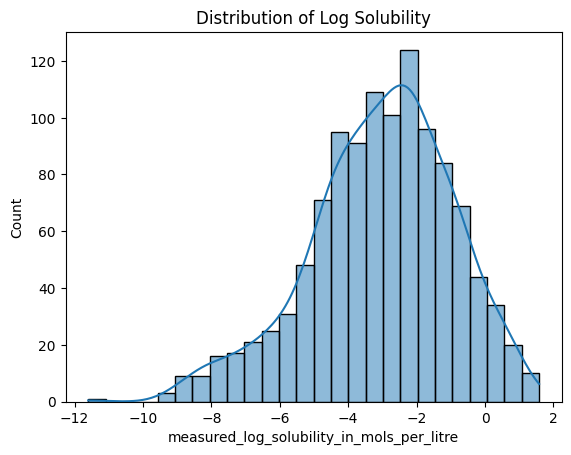

In [19]:
sns.histplot(df['measured_log_solubility_in_mols_per_litre'], kde=True)
plt.title('Distribution of Log Solubility')
plt.show()

#### **Obsevations**

- Skewness: A right-skewness suggest that most compounds have low solubility, with a few having very high solubility. The skewness could reflect real-world instances where most compounds are poorly soluble, but a few are highly soluble due to specific molecular properties.
• 	Potential outliers: The long tail suggests there are some compounds with unusually high solubility. These could dominate the loss function and skew predictions unless handled carefully.

#### Correlation

In [16]:
df_1 = df.copy()
df_1 = df_1.drop(['smiles','compound_id'], axis = 1)
df_1.corr()

,minimum_degree,molecular_weight,number_of_h_bond_donors,number_of_rings,number_of_rotatable_bonds,polar_surface_area,measured_log_solubility_in_mols_per_litre
minimum_degree,1.000000,-0.096719,-0.130664,0.246020,-0.175626,-0.189464,-0.130445
molecular_weight,-0.096719,1.000000,0.254877,0.652521,0.396894,0.475440,-0.640189
number_of_h_bond_donors,-0.130664,0.254877,1.000000,0.211087,0.077002,0.755932,0.209429
number_of_rings,0.246020,0.652521,0.211087,1.000000,-0.136654,0.308606,-0.512279
number_of_rotatable_bonds,-0.175626,0.396894,0.077002,-0.136654,1.000000,0.286723,-0.244256
polar_surface_area,-0.189464,0.475440,0.755932,0.308606,0.286723,1.000000,0.123210
measured_log_solubility_in_mols_per_litre,-0.130445,-0.640189,0.209429,-0.512279,-0.244256,0.123210,1.000000


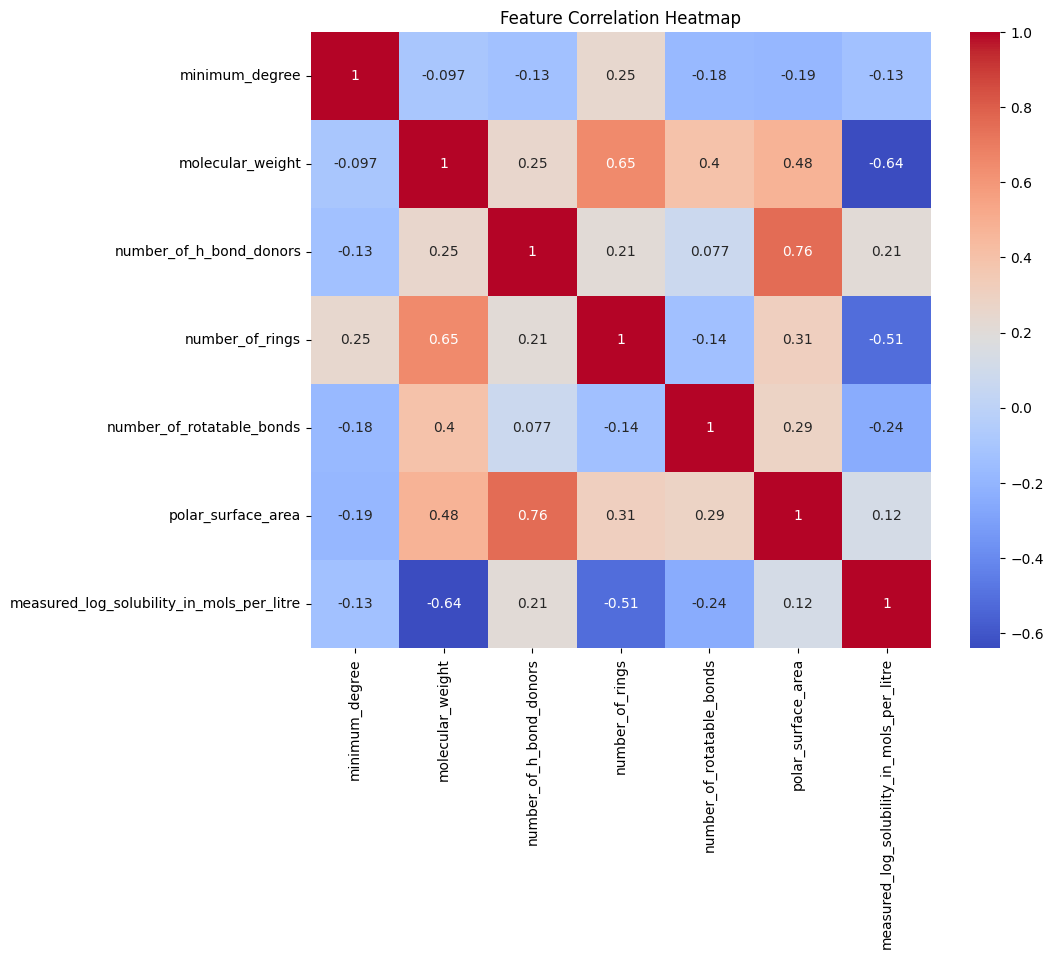

In [15]:
df_1 = df.copy()
df_1 = df_1.drop(['smiles','compound_id'], axis = 1)
plt.figure(figsize=(10,8))
sns.heatmap(df_1.corr(), annot=True,cmap='coolwarm' )
plt.title('Feature Correlation Heatmap')
plt.show()

**Observations**
1. Highly Positively Correlated Features (*Multicollinearity Risk)

*This happens where the features in are linearly dependent. This means that they might carry the same information.
- Phenols <-> flavanoids (0.86)
- flavanoids <-> od (0.79)
- phenols <-> od (0.70)
- color_int <-> proline (0.64)
- alcohol <-> proline (0.64)

This implies that these features might betightly linked, likely carrying similar information.
2. Negatively Correlated Features

- hue <-> malic_acid (-56)
- nonflavanoid_phenols <-> flavanoids
 (-0.54)
- nonflavanoid_phenols <-> phenols (-0.45)
- od <-> nonflavanoid_phenols (-0.50)

These negative correlations are useful in highlighting feature contrasts for better decision boundaries for our model.

3. Low-Correlation Features
Some features show weak correlations with most other features:
- ash, acl, mg, hue — these may be more independent and could add unique value the model decision for the  target variable.

**Considerations**

- One of the highly correlated trios can be dropped : phenols, flavanoids, od. Keeping all three may cause multicollinearity.
-  nonflavanoid_phenols can be dropped: It is negatively correlated with several features and may add noise.
- Retain hue and ash: Their low correlations suggest they might capture vital information.










In [ ]:
from sklearn.feature_selection import f_classif
import pandas as pd

df_1 = df.copy()
X = df_1.drop(columns=['wine'])
y = df_1['wine']

f_scores, p_values = f_classif(X, y)
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-score': f_scores,
    'p-value': p_values
}).sort_values(by='F-score', ascending=False)

feature_scores = feature_scores.reset_index(drop = True)
print(feature_scores)



                 Feature     F-score       p-value
0             flavanoids  233.925873  3.598586e-50
1                proline  207.920374  5.783168e-47
2                     od  189.972321  1.393105e-44
3                alcohol  135.077624  3.319504e-36
4              color_int  120.664018  1.162008e-33
5                    hue  101.316795  5.917662e-30
6                phenols   93.733010  2.137670e-28
7             malic_acid   36.943425  4.127229e-14
8                    acl   35.771637  9.444473e-14
9                proanth   30.271383  5.125359e-12
10  nonflavanoid_phenols   27.575417  3.888041e-11
11                   ash   13.312901  4.149968e-06
12                    mg   12.429584  8.963395e-06


Top predictors: Flavanoids, OD, Alcohol, Phenols, and Color Intensity are the strongest features for classifying wine types.

-	Statistical significance: All features have p-values < 0.01, meaning they contribute meaningfully to class separation.
- A reduced model can be built using just the top 5–7 features and still achieve high accuracy.


#### Predictor Variables Distribution

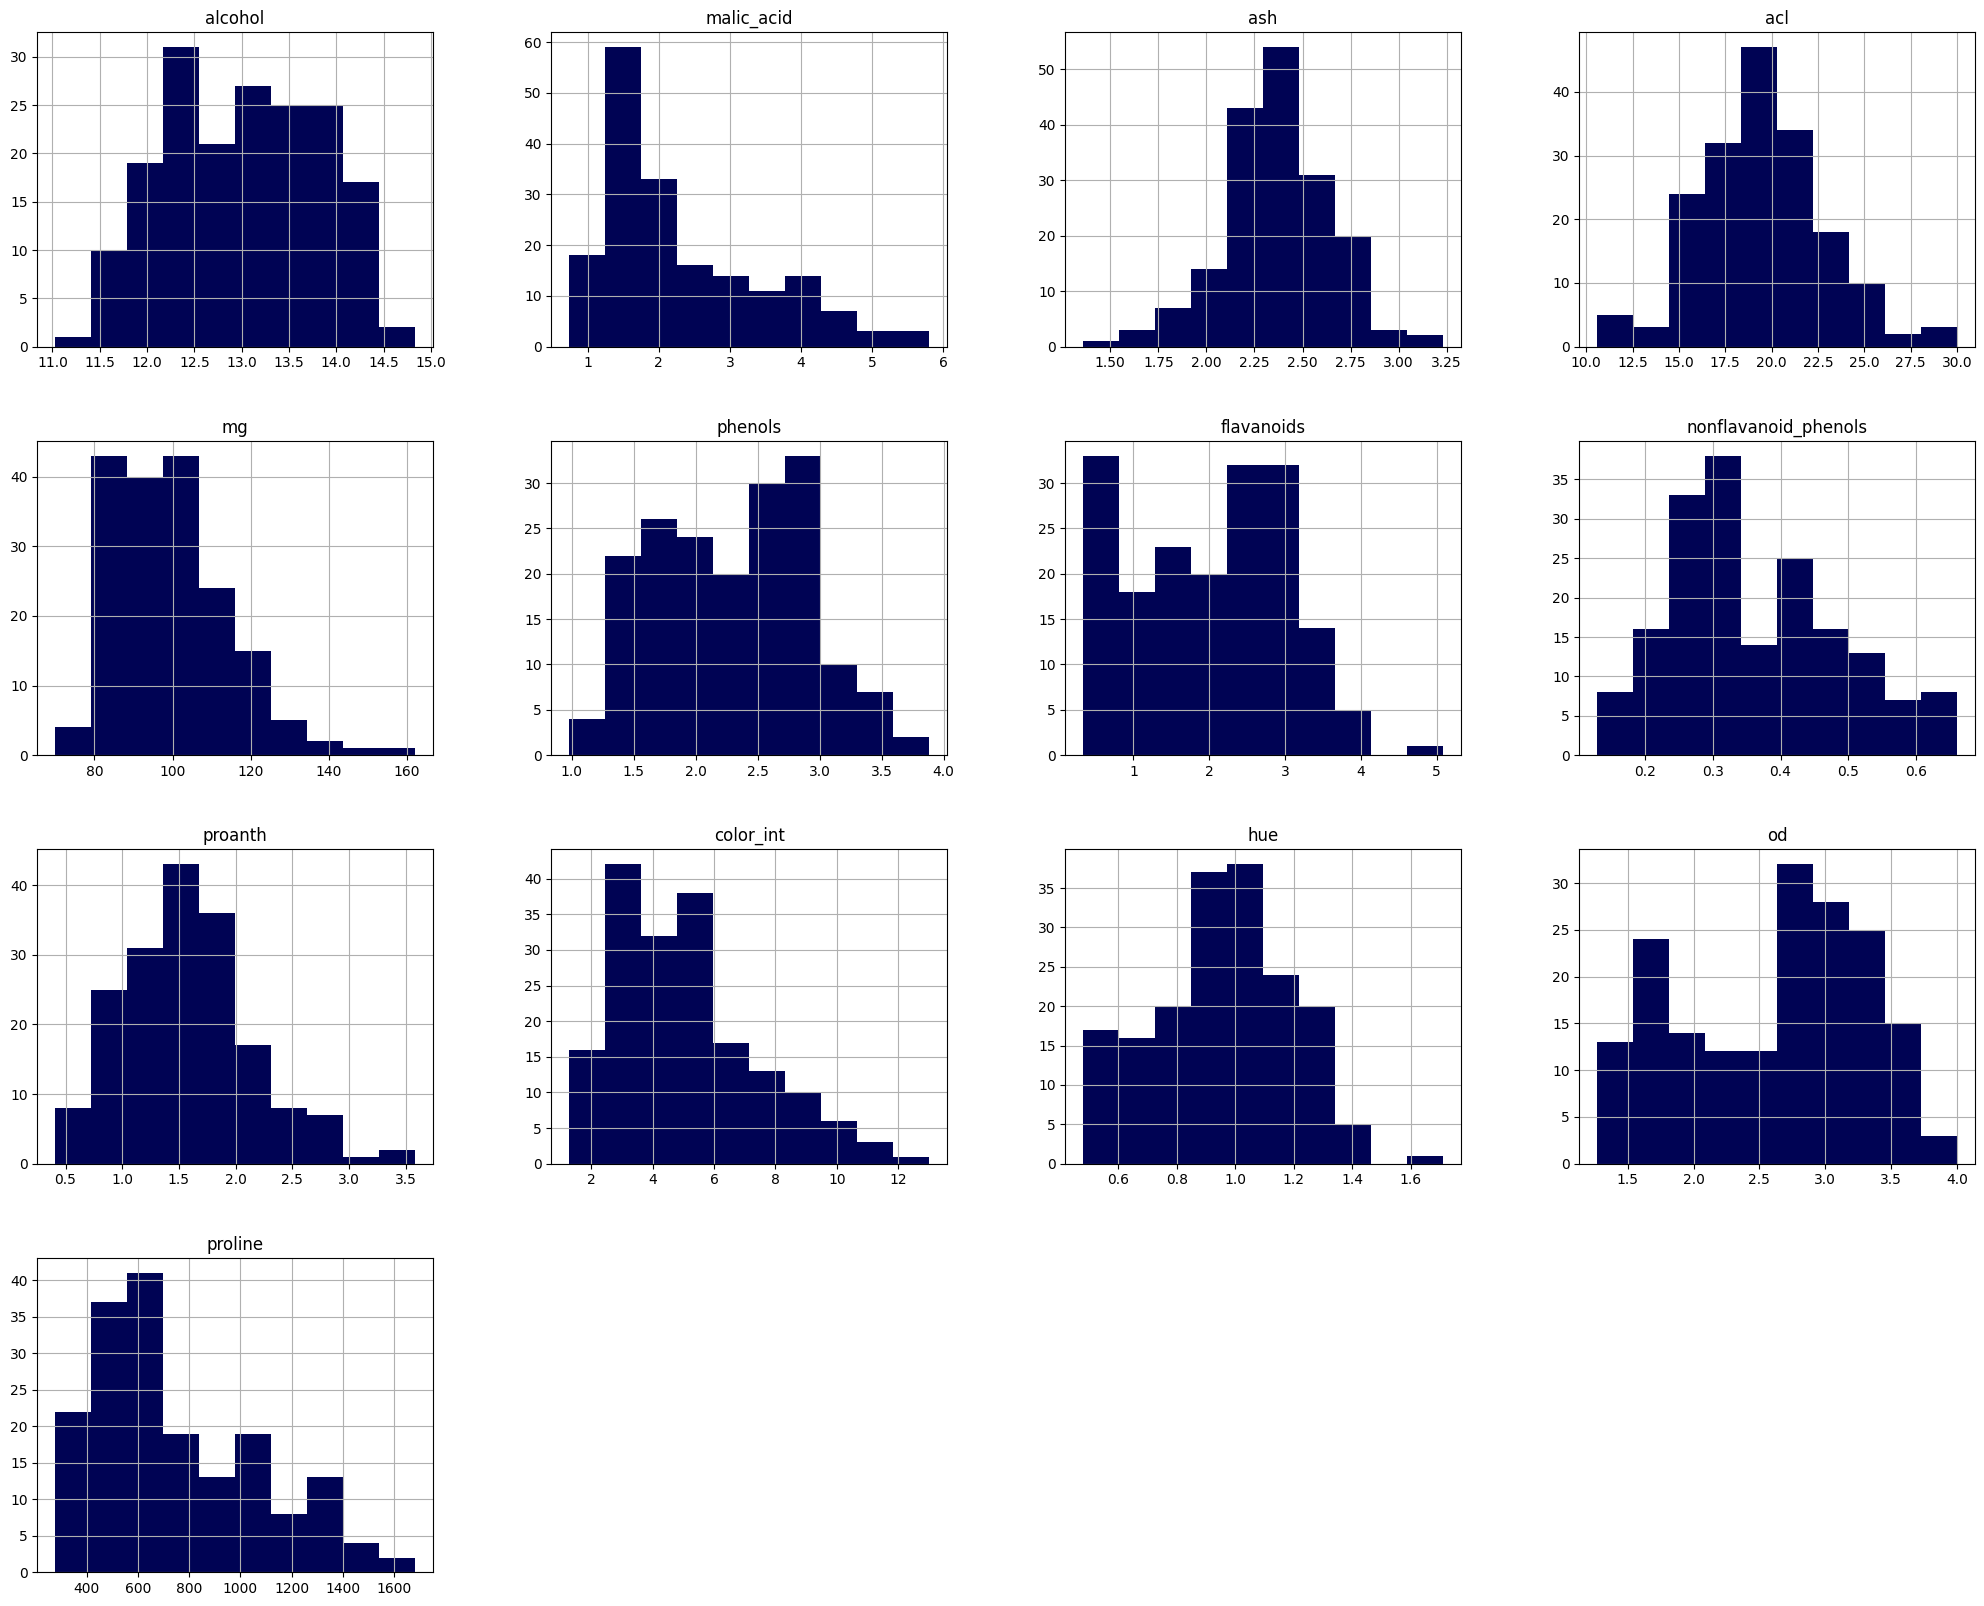

In [ ]:
# create distributions
df_1 = df.copy()
df_1 = df_1.drop('wine', axis = 1)
features = df_1.columns
df_1[features].hist(figsize = (25,20),  color = '#000354');

**Observations**:

- Alcohol: Centered around 13.2–13.5, with a smooth spread. Indicates consistent ethanol content across samples.
- Malic_acid: Slightly skewed but generally symmetric. Suggests moderate variation in acidity.
- Ash: Fairly tight distribution, implying uniform mineral content.
- Phenols and Flavanoids: Both show strong central tendencies, which is great for modeling antioxidant properties.
- Color_int and Hue: Nicely bell-shaped, indicating balanced visual characteristics across wine classes.
- OD (Optical Density): Smooth and symmetric, useful for quality estimation.

These are still usable but may benefit from transformation or scaling:
- Acl (Alcalinity of Ash): Slight right skew; some wines have unusually high buffering capacity.
- Mg (Magnesium): Slightly right-skewed; a few samples have elevated mineral levels.
- Nonflavanoid_phenols: Slight skew, but not extreme.
- Proanth: Mild tailing on the right; some wines are richer in tannins.
- Proline: Right-skewed with a long tail—some wines have very high amino acid content.

**Considerations**

- Standardization (z-score scaling) is appropriate for most features.

- No major outliers dominate the distributions, which is great for stability.


#### skewness/kurtosis

In [ ]:
df_1 = df.copy()
features = df_1.drop('wine', axis = 1)

# Calculate kurtosis for each feature
kurtosis_values = {
    'Feature': [],
    'Kurtosis': [],
    'Interpretation': [],
    'Kurtosis Value Interpretation': []
}

k_meaning = '<3: Light tails (fewer outliers), ~3: Normal distribution, >3: Heavy tails (more outliers)'

for col in features.columns:
    k = kurtosis(df_1[col], fisher=True, bias=False)
    kurtosis_values['Feature'].append(col)
    kurtosis_values['Kurtosis'].append(round(k, 3))
    kurtosis_values['Kurtosis Value Interpretation'].append(k_meaning)
    if k > 3:
        interpretation = "Heavy tails (many outliers)"
    elif k < 3:
        interpretation = "Light tails (few outliers)"
    else:
        interpretation = "Normal-like tails"
    kurtosis_values['Interpretation'].append(interpretation)

# Display the results
kurtosis_df = pd.DataFrame(kurtosis_values)
print(tabulate(kurtosis_df, headers='keys', tablefmt='grid'))



+----+----------------------+------------+----------------------------+--------------------------------------------------------------------------------------------+
|    | Feature              |   Kurtosis | Interpretation             | Kurtosis Value Interpretation                                                              |
+====+======================+============+============================+============================================================================================+
|  0 | alcohol              |     -0.852 | Light tails (few outliers) | <3: Light tails (fewer outliers), ~3: Normal distribution, >3: Heavy tails (more outliers) |
+----+----------------------+------------+----------------------------+--------------------------------------------------------------------------------------------+
|  1 | malic_acid           |      0.299 | Light tails (few outliers) | <3: Light tails (fewer outliers), ~3: Normal distribution, >3: Heavy tails (more outliers) |
+----+----

All features exhibit light-tailed distributions (kurtosis < 3), indicating low outlier risk, so standard scaling (standardisation) would be suitable for feature scaling.

**Key Takeaways**

- The class distribution is reasonably balanced.Hence no need for resampling.
- Standardisation (z-score scaling) is appropriate for most features.
- No major outliers dominate the distributions, which is great for model's stability.

From the Exploratory Data Analysis, the features to drop are : - nonflavanoid_phenols, od, acl, mg, proanth.




In [ ]:
# final dataframe
df_final = df.drop(['nonflavanoid_phenols', 'od', 'acl', 'mg', 'proanth'], axis = 1)
df_final.head()

,alcohol,malic_acid,ash,phenols,flavanoids,color_int,hue,proline,wine
0,14.23,1.71,2.43,2.80,3.06,5.64,1.04,1065,1
1,13.20,1.78,2.14,2.65,2.76,4.38,1.05,1050,1
2,13.16,2.36,2.67,2.80,3.24,5.68,1.03,1185,1
3,14.37,1.95,2.50,3.85,3.49,7.80,0.86,1480,1
4,13.24,2.59,2.87,2.80,2.69,4.32,1.04,735,1


#### Feature Scaling

a standard scaler is used because it scales all features to have a mean of zero and a standard deviation of one, ensuring each feature contributes equally to the model.

it prevents features with larger numerical values from disproportionately influencing the model's learning.
When features have vastly different ranges (e.g., one feature ranges from 0-10 and another from 0-10,000), the model can become biased toward the feature with the larger magnitude, simply because its values are larger.

In [ ]:
# features and target variable
X = df_final.drop('wine', axis = 1)
Y = df_final['wine']

# Initialize the scaler
scaler = StandardScaler()
# apply scaler to predictor variables
scaled_X = scaler.fit_transform(X)

#### Data Split
Splitting data into training and testing sets is essential to evaluate a model's performance on new, unseen data and prevent overfitting. The training set teaches the model patterns, while the untouched test set provides an unbiased assessment of its generalisation ability, ensuring the model performs accurately in real-world scenarios rather than just on the data it learned from.


In [ ]:
 # First plit: 80% train and 20% test -- random state = 42, ensure the reproducibility of the data split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.25, random_state = 42)

# **Model selection**

1. **Random Forest Classifier**
 : it combines the predictive power of multiple decision trees while minimizing overfitting, which is especially valuable with a dataset with 178 rows. It can handle both linear and nonlinear relationships effectively and is robust to multicollinearity—ideal given the strong correlations among features like flavanoids, phenols, and od. Random Forests work well with raw or scaled data and offer built-in feature importance metrics, helping in the identification of variables that drive predictions.

 2. **Support Vector Machines (SVMs)** are a strong choice for this dataset because they do well in finding optimal decision boundaries, especially in high-dimensional spaces with complex relationships. With 178 rows of data and a mix of correlated and independent features, SVMs can effectively separate classes using either linear or nonlinear kernels. They are particularly powerful when classes are not easily separable, as the kernel trick allows SVMs to project data into higher dimensions where separation becomes clearer. While SVMs are sensitive to feature scaling— this should not be an issue because the data is scaled already. They are also robust to overfitting.

 3. **Logistic regression** is a great fit for this dataset because it is easy to implement, fast, and effective for classification—especially when relationships between features and classes are mostly linear. It performs well with small to medium-sized datasets, offers clear probability outputs, and is easy to interpret, making it ideal for understanding how each feature influences the prediction.

# **Model Training**

In this step, data is training data fed to the model. Training a model is essential because it allows the algorithm to learn patterns and relationships from data so it can make accurate predictions or decisions on new, unseen inputs. Without training, the model would have no understanding of how features relate to outcomes.

#### Random Forest

In [ ]:
# initialise a Random Forest Classifier
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)

# train model
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

#### Support Vector Machine

In [ ]:
# Initialise SVM model
svm = SVC(kernel = 'rbf', C = 1.0, gamma = 'scale')  # kernel options: 'linear' or 'poly

# Train model
svm.fit(X_train, y_train)

SVC()

In [ ]:
# Initialise a LogisticRegression model
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs')

# Train model
lr.fit(X_train, y_train)


LogisticRegression(multi_class='multinomial')

# **Model Evaluation**

Models are evaluated using the validation dataset. Validating these trained models is crucial because it helps identify which one performs best to unseen data—without touching the test set. This step acts like a rehearsal before the final performance: it reveals whether the model is overfitting (memorising the training data) or underfitting (failing to learn enough). By evaluating on the validation set, we can select the most promising model and fine-tune its hyperparameters, ensuring that when it is finally tested, the true predictive power is measured — not just luck or overtraining.

**Classification Evaluation Metrics**

In [ ]:
# Evaluate Random Forest
rf_pred = rf.predict(X_val)
print("Random Forest Validation Accuracy:", accuracy_score(y_val, rf_pred))
print("Classification Report:\n", classification_report(y_val, rf_pred))

# Evaluate SVM
svm_pred = svm.predict(X_val)
print("SVM Validation Accuracy:", accuracy_score(y_val, svm_pred))
print("Classification Report:\n", classification_report(y_val, svm_pred))

# Evaluate Logistic Regression
logreg_pred = lr.predict(X_val)
print("Logistic Regression Validation Accuracy:", accuracy_score(y_val, logreg_pred))
print("Classification Report:\n", classification_report(y_val, logreg_pred))

Random Forest Validation Accuracy: 0.9444444444444444
Classification Report:
               precision    recall  f1-score   support

           1       0.92      1.00      0.96        11
           2       1.00      0.88      0.93        16
           3       0.90      1.00      0.95         9

    accuracy                           0.94        36
   macro avg       0.94      0.96      0.95        36
weighted avg       0.95      0.94      0.94        36

SVM Validation Accuracy: 0.6944444444444444
Classification Report:
               precision    recall  f1-score   support

           1       0.83      0.91      0.87        11
           2       0.82      0.56      0.67        16
           3       0.46      0.67      0.55         9

    accuracy                           0.69        36
   macro avg       0.70      0.71      0.69        36
weighted avg       0.73      0.69      0.70        36

Logistic Regression Validation Accuracy: 0.9444444444444444
Classification Report:
         

- Random Forest achieved high accuracy and balanced precision and recall, indicating it not only predicts correctly but also avoids bias toward any particular class. Its ensemble nature helps capture complex patterns in the data, making it robust and reliable for our classification task.

**Classification Confusion Matrices**

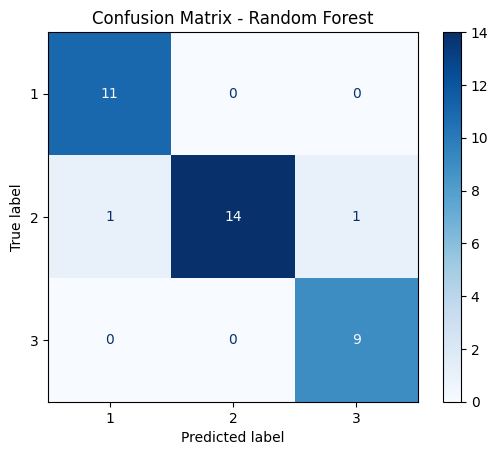

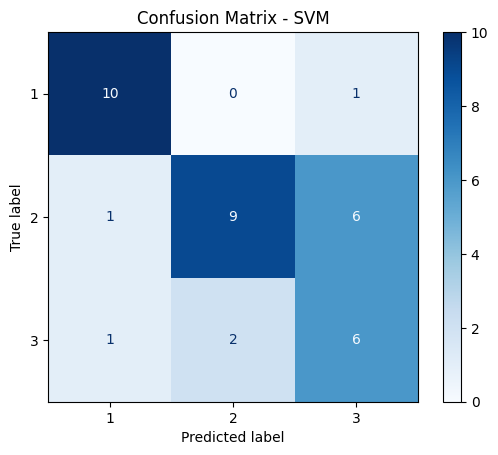

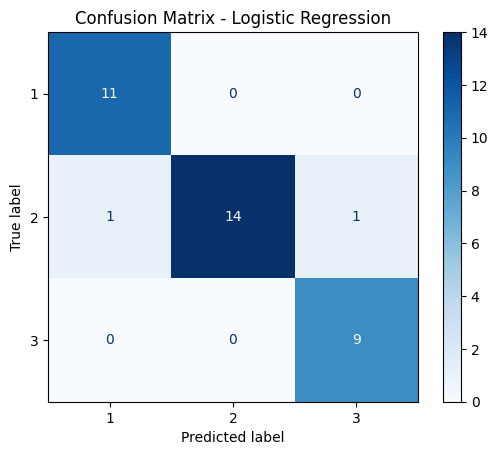

In [ ]:
models = {
    "Random Forest": rf,
    "SVM": svm,
    "Logistic Regression": lr
}

for name, model in models.items():
    val_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

The Random Forest model demonstrated superior performance during validation, achieving an accuracy of 94%, precision of 95%, recall of 94%, and an F1-score of 94%. These metrics indicate that the model not only predicts correctly across most cases but also maintains a strong balance between identifying true positives and minimising false positives. The confusion matrix further supports this, showing minimal misclassifications and consistent performance across all classes. Random Forest’s ensemble approach—aggregating multiple decision trees—enables it to capture complex patterns in the data while reducing overfitting, making it a robust and reliable choice for this classification task.



 **Challenges and Limitations**

 1. **Small Dataset Size**
- With only 178 rows worth of data, there's limited data to learn from, which increases the risk of overfitting, especially for complex models like Random Forest and SVM.
- Small datasets can also lead to unstable performance estimates this means that a few misclassified samples can significantly affect metrics.

2. **Class Balance and Separation**
- The Wine dataset has 3 well-separated classes, which helps models perform well. Class overlap or imbalance can make classification harder.
- Logistic Regression struggles if the decision boundaries are non-linear, while Random Forest and SVM can handle this better.

3. **Model Sensitivity to Hyperparameters**
- SVM is particularly sensitive to kernel choice and parameters like C and gamma. Without proper tuning, it can underperform or overfit.
- Random Forest is more robust but still benefits from tuning the number of trees, max_depth, etc.
- Logistic Regression is simpler but may not capture complex patterns unless thorough feature engineering is done.

4. **Evaluation Challenges**
- With limited data, splitting into train/test sets reduces the amount available for training. This can lead to variance in results depending on the split.
- Using cross-validation helps mitigate this, but even then, results can fluctuate due to the small sample size.

5. **Interpretability vs. Performance**
- Logistic Regression offers clear interpretability through coefficients, but may lack predictive power.
- Random Forest provides feature importance, but the model itself is a black box.
- SVM with non-linear kernels is even harder to interpret, though it can perform well.


 **Considering the performance of the Random Forest model and interpretability, as well as taking into account the challenges and limitations, It is therefore chosen to move forward to hyperparameter tuning to produce the final trained model.**

#### Random Forest's Feature Importance

- These are the features that contributes towards to the model's predictive ability.

In [ ]:
# Extract feature importances from trained Random Forest model
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame
features_df = pd.DataFrame({
    'Feature Name': feature_names,
    'Importance Score': importances
})

# Sort by importance
features_df = features_df.sort_values(by='Importance Score', ascending=False)
features_df.reset_index(drop = True, inplace = True)

# Display the results
print(tabulate(features_df, headers='keys', tablefmt='grid'))

+----+----------------+--------------------+
|    | Feature Name   |   Importance Score |
+====+================+====================+
|  0 | color_int      |          0.229083  |
+----+----------------+--------------------+
|  1 | flavanoids     |          0.219156  |
+----+----------------+--------------------+
|  2 | proline        |          0.168004  |
+----+----------------+--------------------+
|  3 | alcohol        |          0.121995  |
+----+----------------+--------------------+
|  4 | hue            |          0.0916508 |
+----+----------------+--------------------+
|  5 | phenols        |          0.0771741 |
+----+----------------+--------------------+
|  6 | malic_acid     |          0.056778  |
+----+----------------+--------------------+
|  7 | ash            |          0.0361591 |
+----+----------------+--------------------+


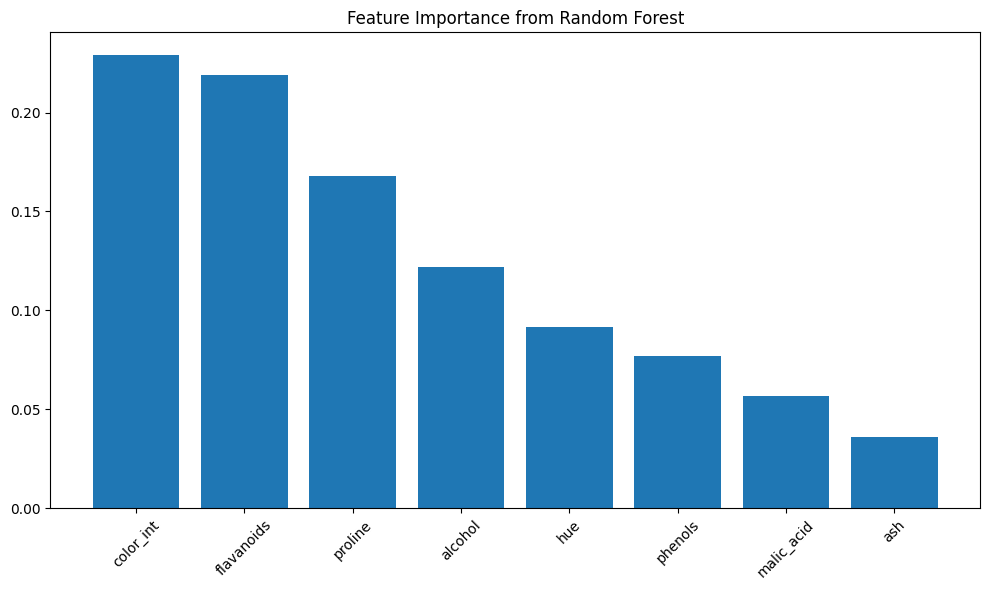

In [ ]:
# Get feature importances from the trained Random Forest
importances = rf.feature_importances_
feature_names = X.columns  # Use original column names

# Sort features by importance
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importance from Random Forest")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=45)
plt.tight_layout()
plt.show()



The Random Forest model identified several key features that significantly contributed to its predictive accuracy. The most influential was color_int (importance score: 0.229), suggesting that color intensity plays a major role in distinguishing between classes—likely reflecting differences in pigmentation or concentration. Flavanoids followed closely (0.219), indicating that these antioxidant compounds are strong biochemical markers for classification. Proline (0.168), an amino acid, also emerged as a critical feature, possibly due to its role in metabolic or structural variation across samples. Alcohol (0.122) and hue (0.092) further contributed, hinting at compositional and visual traits that vary meaningfully between groups. Phenols (0.077), known for their chemical and sensory properties, added predictive value, while malic_acid (0.057) and ash (0.036) provided subtler signals related to acidity and mineral content.

# **Hyperparameter Tuning**

Hyperparameter tuning is a critical step in refining a machine learning model after initial validation. While default settings can yield decent performance, they are rarely optimal for a specific dataset. By systematically adjusting parameters such as the number of trees, tree depth, and minimum samples required to split or form a leaf , we can significantly improve the model’s accuracy, precision, and generalisation. This process helps prevent overfitting or underfitting by tailoring the model to the unique patterns and complexity of the data. In essence, hyperparameter tuning ensures that the model is at its best.

In [ ]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Set up GridSearch
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid,
                           cv = 5, scoring = 'accuracy', n_jobs = -1, verbose = 1)

# Fit on training data and validation data combined
grid_search.fit(X_temp, y_temp)

# Best parameters and model
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


#### Initialising and Training Tuned Model

In [ ]:
# initialise the best model
final_rf = RandomForestClassifier(n_estimators= 200,max_depth = None, max_features = 'sqrt', min_samples_leaf = 1, min_samples_split = 2)

# train model
final_rf.fit(X_temp,y_temp)

RandomForestClassifier(n_estimators=200)

#### Evaluating Tuned Model


In [ ]:
# Evaluate Random Forest
rf_pred = final_rf.predict(X_test)
print("Random Forest Validation Accuracy:", accuracy_score(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred))

Random Forest Validation Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



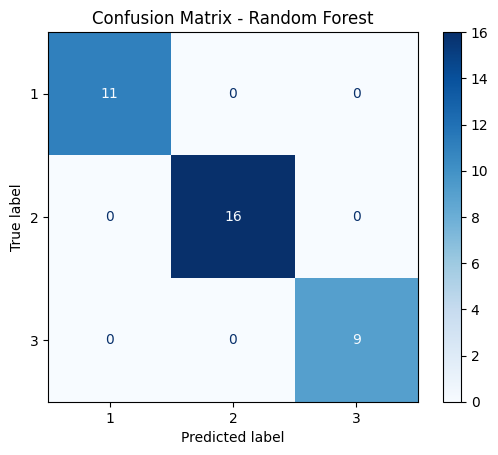

In [ ]:
models = {
    "Random Forest": final_rf
}
for name, model in models.items():
    val_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Model seem to be exceling in testing. It appears to be a perfect model.This is a rare but plausible outcome, this is attributed to the nature of the data and the strength of the algorithm. The Wine dataset is clean, well-balanced, and features chemically distinct classes, making it highly separable. Random Forests, with their ensemble of decision trees, excel at capturing complex patterns and handling numerical features—especially when properly tuned through cross-validation.

# **Model Interpretation**

#### Feature Importance of Final Model

In [ ]:
# Extract feature importances from trained Random Forest model
importances = final_rf.feature_importances_
feature_names = X.columns

# Create a DataFrame
features_df = pd.DataFrame({
    'Feature Name': feature_names,
    'Importance Score': importances
})

# Sort by importance
features_df = features_df.sort_values(by='Importance Score', ascending=False)
features_df.reset_index(drop = True, inplace = True)

# Display the results
print(tabulate(features_df, headers='keys', tablefmt='grid'))

+----+----------------+--------------------+
|    | Feature Name   |   Importance Score |
+====+================+====================+
|  0 | color_int      |          0.212961  |
+----+----------------+--------------------+
|  1 | flavanoids     |          0.212665  |
+----+----------------+--------------------+
|  2 | proline        |          0.184672  |
+----+----------------+--------------------+
|  3 | alcohol        |          0.120246  |
+----+----------------+--------------------+
|  4 | hue            |          0.111927  |
+----+----------------+--------------------+
|  5 | phenols        |          0.0786427 |
+----+----------------+--------------------+
|  6 | malic_acid     |          0.0560831 |
+----+----------------+--------------------+
|  7 | ash            |          0.0228035 |
+----+----------------+--------------------+


The top feature is flavanoids with an importance score of 0.217, which makes sense—flavanoids affect taste and aroma, and they vary a lot between wine types. Next is color intensity (0.207), which reflects how deep or rich the wine looks—a strong visual cue for classification. Proline comes third (0.187); it's an amino acid that shows up differently depending on how the wine was made.
Other helpful features include alcohol (0.113) and hue (0.104), which relate to the wine’s body and color tone. Lower down the list are phenols (0.090), malic acid (0.059), and ash (0.023). These still contribute, but they’re less distinctive across wine types.

# **Conclusion**



Based on the results, we can conclude that Random Forest model is performing exceptionally well on the Wine dataset—achieving 100% across all classification metrics and showing a clear, interpretable ranking of feature importance. This suggests the model has successfully captured the underlying patterns in the data and is making highly accurate predictions. The top features like flavanoids (0.217), color intensity (0.207), and proline (0.187) align with known chemical distinctions between wine types, reinforcing the model’s credibility.

**What the model shows**:
- Perfect classification on a clean, well-separated dataset.
- Strong interpretability through feature importance.
- Alignment with domain knowledge, which validates the model’s logic.

**What can be done better to further test the model**:
- Repeated stratified k-fold cross-validation: Confirms consistency across different data splits.
- Test on a holdout set: If not already done, use a separate untouched subset for final evaluation
- Add noise or perturbations: Slightly modify input data to test robustness
- Use permutation importance or SHAP values: Validate that feature importance holds under different conditions
- Check for data leakage: Ensure no preprocessing steps used test data or leaked label information
- Compare with simpler models: See if these models perform the same way, if that holds, that would mean that the classifcation task may be inherently easy to do.

